In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("OnlineRetail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df = df.dropna(subset=['CustomerID'])

In [4]:
df = df[df['Quantity'] > 0]

In [5]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,33,31,711.79
12348.0,24,17,892.80
12370.0,24,91,1868.02
12377.0,21,43,1001.52
12383.0,19,37,600.72


In [8]:
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

In [9]:
from sklearn.model_selection import train_test_split

X = rfm[['Recency','Frequency','AOV']]
y = rfm['Monetary']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train,y_train)

RandomForestRegressor()

In [11]:
predictions = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test,predictions)
rmse = np.sqrt(mean_squared_error(y_test,predictions))

print("MAE:",mae)
print("RMSE:",rmse)

MAE: 149.1019205128205
RMSE: 821.9372762759308


In [13]:
rfm['Predicted_LTV'] = model.predict(X)

rfm['Segment'] = pd.qcut(rfm['Predicted_LTV'], q=3, labels=['Low Value','Medium Value','High Value'])

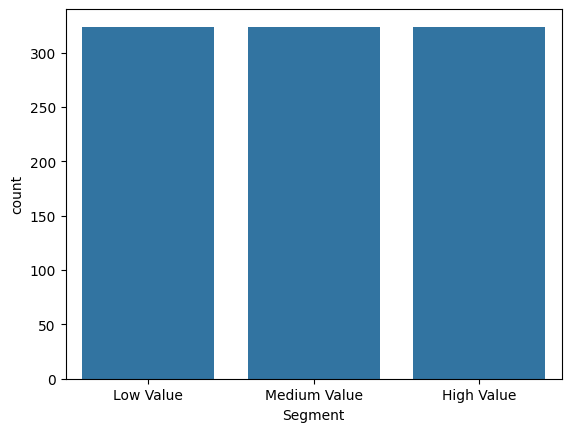

In [14]:
sns.countplot(x='Segment', data=rfm)
plt.show()

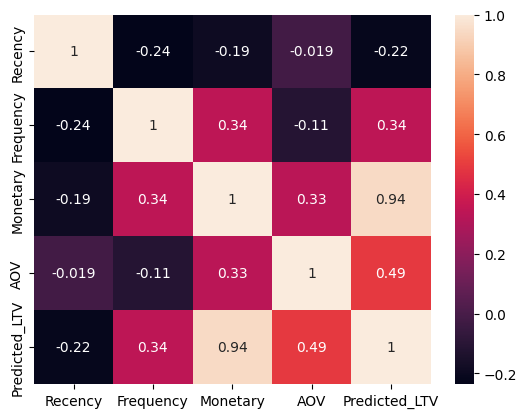

In [16]:
sns.heatmap(rfm.drop('Segment', axis=1).corr(), annot=True)
plt.show()

In [17]:
rfm.to_csv("customer_ltv_predictions.csv")